| Problem | nº asteroids | frame center | x axis | $\Omega$ (angular speed)| perturbing body |
|---|---|---|---|---|---|
| Hill + SRP (single ast) | single | asteroid          | sun->asteroid        | around Sun | None |
| Hill 4 body + SRP       | binary | main asteroid     | sun->asteroid        | around Sun | small asteroid |
| Bicircular + SRP        | binary | CoM binary system | main->small asteroid | around CoM | Sun |

Dynamics:

$$\ddot{\mathbf{r}}+2 \Omega \times \dot{\mathbf{r}}=\nabla U + \mathbf{a}_s$$

- $\tilde{\mu}$ : main asteroid
- $\tilde{\mu}_3$ : smaller asteroid
- $\mu = m_2/(m_1+m_2)$ : ast1 and ast2
- $\mu_3 = m_3/(m_1+m_2)$ : $m_3$ = Sun mass

- $\mathbf{r}$ : origin to sail
- $\mathbf{r}_1$ : ast1 to sail
- $\mathbf{r}_2$ : ast2 to sail
- $\mathbf{r}_3$ : origin to perturbing body
- $\mathbf{r}_4$ : sail to perturbing body

In [ ]:
import numpy as np
import importlib
import sympy as sp

import systems
importlib.reload(systems)

import solar_sail_control
importlib.reload(solar_sail_control)
from solar_sail_control import ControlledHillProblem

import find_orbits.nonlinear as nonlinear
import find_orbits.linearize as linearize
importlib.reload(nonlinear)
importlib.reload(linearize)

AU_TO_KM = 149_597_870.7
H_TO_S = 60*60

# Hill Problem for a single asteroid

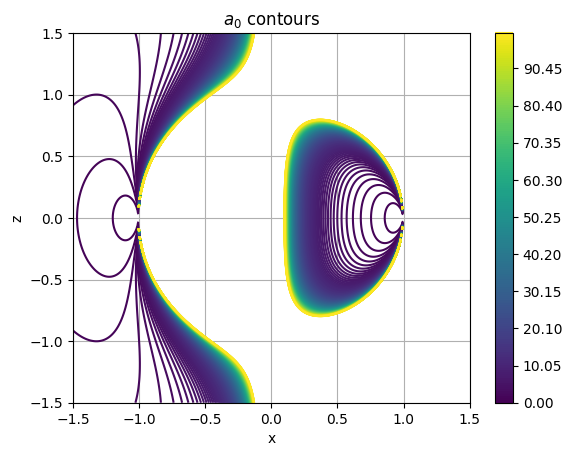

In [21]:
mu_tilde = 14.2568 # km3/s2 
a = 2.36 * AU_TO_KM # km
Omega = np.sqrt(mu_tilde/a**3) # /s
hill = systems.HillProblem(Omega,mu_tilde)


x = np.linspace(-1.5, 1.5, 400)
z = np.linspace(-1.5, 1.5, 400)
levels = np.linspace(0, 100, 200)
hill.plot_a0_contours(x,z,"xz",levels)

# Bicircular

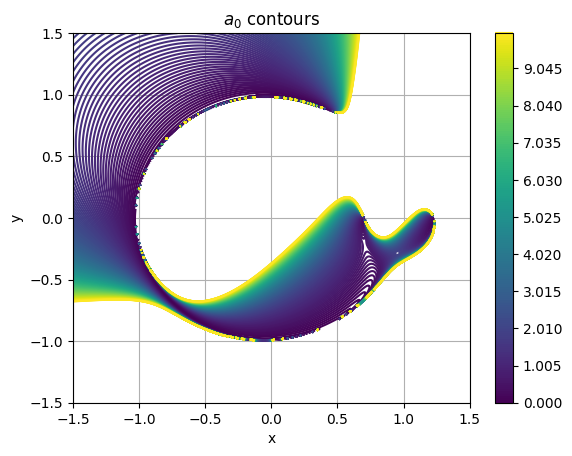

In [22]:
mu = 0.0543
m3 = 1.9885e30 # kg (Sun mass)
mu3 = m3/2.472e12
a = 1*AU_TO_KM # km
kappa = 2.54 # km
Omega_s = 0.998
bicircular = systems.Bicircular(mu,mu3,Omega_s,a,kappa)


x = np.linspace(-1.5, 1.5, 400)
y = np.linspace(-1.5, 1.5, 400)
levels = np.linspace(0, 10, 200)
t = 0.25*np.pi/Omega_s
bicircular.plot_a0_contours(x,y,"xy",levels,t)

# Nonlinear Approximations

In [ ]:
prev_solutions = nonlinear.all_nonlinear_approximations(3)
tau = sp.Symbol("tau")
T = sp.Function("T")(tau)
prev_solutions[2][0][sp.cos(T)]

# subs Fijk

# 2D AEP Stabilization

Assumptions:

- Linearized 
- $\alpha$ is not a state variable, but a control variable (irrealistic).
- 2D
- zx plane

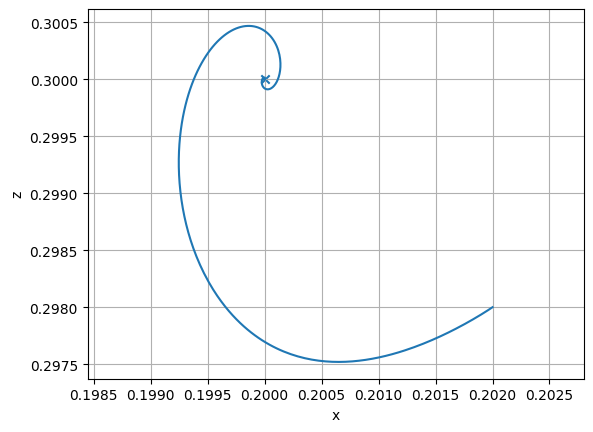

In [15]:
# Hill Problem
mu_tilde = 14.2568 # km3/s2 
a = 2.36 * AU_TO_KM # km
Omega = np.sqrt(mu_tilde/a**3) # /s
controlled_hill = ControlledHillProblem(Omega,mu_tilde)

# AEP
r_eq = np.array([0.2,0,0.3])
controlled_hill.set_AEP(r_eq)

# weights
Q = np.diag([100, 100, 100, 1, 1, 1]) # state
R = np.array([[1]])                   # controller
controlled_hill.set_weights(Q,R)

# solve initial value problem
perturbation = np.array([0.002,0,-0.002,0,0,0])
t_span=(0, 50)
controlled_hill.add_perturbation(t_span,perturbation)

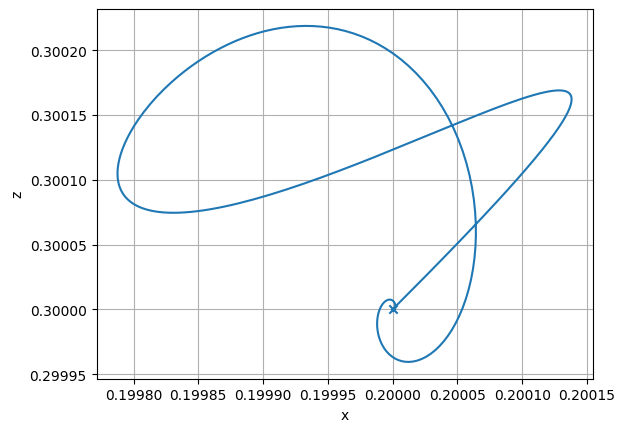

In [16]:
perturbation = np.array([0,0,0,0.01,0,0.01])
t_span=(0, 50)
controlled_hill.add_perturbation(t_span,perturbation)

# Tests

10
